# Multiclass classification — metric semantics and class-level diagnostics


## Goal
Exercise the multiclass contract with imbalanced classes, an extended metric panel, OOF probability outputs, class-level error analysis and fold stability. This notebook deliberately uses both canonical weighted names (`f1`, `precision`, `recall`) and explicit macro/micro variants.


In [1]:
import os
os.environ.setdefault("MPLBACKEND", "Agg")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DEMO_TEST = os.getenv("SABER_DEMO_TEST") == "1"

def balanced_fold_labels(y, n_splits):
    """Demo-only external memberships. Production partition generation belongs to BioSieve."""
    y = np.asarray(y)
    folds = np.empty(len(y), dtype=int)
    for label in np.unique(y):
        idx = np.flatnonzero(y == label)
        folds[idx] = np.arange(len(idx)) % n_splits
    return folds

from sklearn.datasets import make_classification
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
from saber import validate
from saber.datasets import DatasetBundle, PartitionPlan


In [2]:
n_samples = 210 if DEMO_TEST else 480
X, y = make_classification(
    n_samples=n_samples, n_features=20, n_informative=12, n_redundant=3,
    n_classes=3, n_clusters_per_class=1, weights=[0.55,0.30,0.15],
    class_sep=1.15, random_state=7,
)
ids = [f"multi_{i:04d}" for i in range(len(y))]
dataset = DatasetBundle(X=X, y=y, sample_ids=ids,
                        feature_names=[f"f{i:02d}" for i in range(X.shape[1])])
plan = PartitionPlan.from_predefined_folds(
    sample_ids=dataset.sample_ids,
    fold_assignments=balanced_fold_labels(y, 5),
    dataset_fingerprint=dataset.fingerprint,
    metadata={"source":"demo_external_memberships"},
)


In [3]:
metrics = (
    "accuracy", "balanced_accuracy", "precision", "recall", "f1",
    "precision_macro", "recall_macro", "f1_macro", "f1_micro", "mcc", "log_loss",
)
result = validate(
    dataset=dataset, algorithm="random_forest", partition_plan=plan,
    metrics=metrics, random_state=17,
    model_params={"n_estimators": 80 if DEMO_TEST else 180, "max_depth": 7},
)
oof = result.oof_prediction
assert oof is not None and tuple(oof.classes) == (0,1,2)
fold_metrics = pd.DataFrame([{"fold":f.split_name, **f.evaluation.metrics} for f in result.folds])
per_class = pd.DataFrame(classification_report(y, oof.predictions, output_dict=True, zero_division=0)).T
print(pd.Series(result.aggregate_metrics).round(4))
per_class


accuracy             0.9085
balanced_accuracy    0.8573
f1                   0.9053
f1_macro             0.8830
f1_micro             0.9085
log_loss             0.3790
mcc                  0.8432
precision            0.9128
precision_macro      0.9274
recall               0.9085
recall_macro         0.8573
dtype: float64


,precision,recall,f1-score,support
0,0.892361,0.977186,0.932849,263.000000
1,0.920863,0.876712,0.898246,146.000000
2,0.962264,0.718310,0.822581,71.000000
accuracy,0.908333,0.908333,0.908333,0.908333
macro avg,0.925163,0.857403,0.884559,480.000000
weighted avg,0.911370,0.908333,0.906013,480.000000


## Diagnostic report
The normalized confusion matrix exposes class-specific recall. The second panel compares macro vs weighted F1 across folds, which is especially useful under imbalance. The final panel shows predicted probability calibration qualitatively by true class.


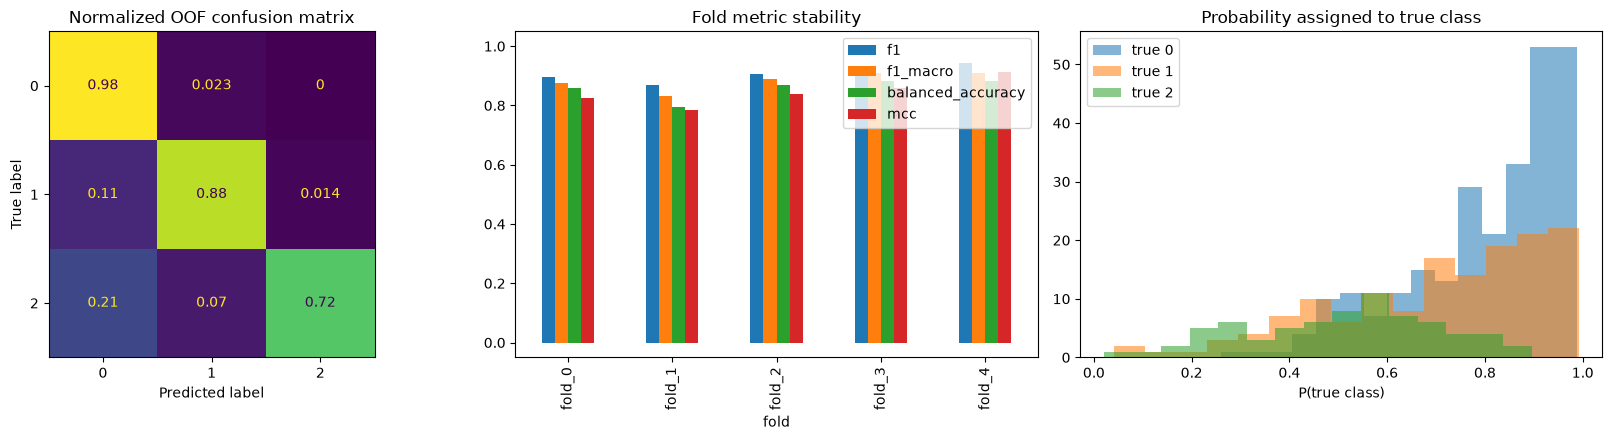

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
ConfusionMatrixDisplay.from_predictions(y, oof.predictions, normalize="true", ax=axes[0], colorbar=False)
axes[0].set_title("Normalized OOF confusion matrix")
fold_metrics.set_index("fold")[["f1", "f1_macro", "balanced_accuracy", "mcc"]].plot.bar(ax=axes[1])
axes[1].set_ylim(-0.05,1.05); axes[1].set_title("Fold metric stability")
proba = np.asarray(oof.probabilities)
for cls in oof.classes:
    axes[2].hist(proba[y==cls, int(cls)], bins=15, alpha=0.55, label=f"true {cls}")
axes[2].set(title="Probability assigned to true class", xlabel="P(true class)"); axes[2].legend()
plt.tight_layout(); FIGURE_COUNT=1


In [5]:
DEMO_CHECKS = {
    "five_folds": result.n_splits == 5,
    "global_multiclass": len(oof.classes) == 3,
    "complete_oof": result.metadata["oof_complete"] is True,
    "extended_metrics": set(metrics) == set(result.aggregate_metrics),
    "canonical_f1_weighted": np.isclose(result.aggregate_metrics["f1"], fold_metrics["f1"].mean()),
    "class_report_has_all_classes": all(str(c) in per_class.index for c in (0,1,2)),
    "figure_created": FIGURE_COUNT == 1,
}
assert all(DEMO_CHECKS.values()), DEMO_CHECKS
DEMO_CHECKS


{'five_folds': True,
 'global_multiclass': True,
 'complete_oof': True,
 'extended_metrics': True,
 'canonical_f1_weighted': np.True_,
 'class_report_has_all_classes': True,
 'figure_created': True}